In [1]:
import requests
from bs4 import BeautifulSoup

url = 'https://store.steampowered.com/search/?tags=1663&category1=998'

headers = {
    'User-Agent': 'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36'
}

response = requests.get(url, headers=headers, verify=False)

print(f'Status Code: {response.status_code}')
print(f'Content Length: {len(response.text)} characters')

/Users/finn/Documents/introductory-apprenticeship-axsa/.venv/lib/python3.13/site-packages/urllib3/connectionpool.py:1110: InsecureRequestWarning: Unverified HTTPS request is being made to host 'store.steampowered.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


Status Code: 200
Content Length: 723850 characters


In [2]:
soup = BeautifulSoup(response.text, 'html.parser')

# Alle Spiele finden
games = soup.find_all('div', class_='responsive_search_name_combined')

print(f'Gefunden: {len(games)} Spiele')

Gefunden: 50 Spiele


In [3]:
for i, game in enumerate(games[:5], 1):
    # Spielname
    title = game.find('span', class_='title')
    name = title.get_text() if title else 'Kein Name'
    
    # Preis
    price = game.find('div', class_='discount_final_price')
    preis = price.get_text() if price else 'Kein Preis'
    
    print(f'Spiel {i}:')
    print(f'  Name: {name}')
    print(f'  Preis: {preis}')
    print()

Spiel 1:
  Name: Counter-Strike 2
  Preis: Free

Spiel 2:
  Name: Cyberpunk 2077
  Preis: CHF 55.99

Spiel 3:
  Name: Team Fortress 2
  Preis: Free

Spiel 4:
  Name: PUBG: BATTLEGROUNDS
  Preis: Free

Spiel 5:
  Name: Apex Legends™
  Preis: Free



In [4]:
for i, game in enumerate(games, 1):
    title = game.find('span', class_='title')
    name = title.get_text() if title else 'Kein Name'
    
    price = game.find('div', class_='discount_final_price')
    preis = price.get_text() if price else 'Kein Preis'
    
    print(f'{i}. {name} - {preis}')

1. Counter-Strike 2 - Free
2. Cyberpunk 2077 - CHF 55.99
3. Team Fortress 2 - Free
4. PUBG: BATTLEGROUNDS - Free
5. Apex Legends™ - Free
6. Rust - CHF 35.99
7. Red Dead Redemption 2 - CHF 14.75
8. Battlefield™ 6 - CHF 69.90
9. THE FINALS - Free
10. Ready or Not - CHF 55.50
11. Borderlands 4 - CHF 34.95
12. DOOM: The Dark Ages - CHF 79.90
13. Escape from Tarkov - CHF 46.99
14. Marvel Rivals - Free
15. Tom Clancy's Rainbow Six Siege - Free
16. SAND: Raiders of Sophie - CHF 27.99
17. Schedule I - CHF 21.99
18. Warhammer 40,000: Darktide - CHF 44.90
19. Arena Breakout: Infinite - Free
20. Sea of Thieves: 2026 Edition - CHF 44.00
21. Destiny 2 - Free
22. Resident Evil Requiem - CHF 69.90
23. Overwatch® - Free
24. Call of Duty®: Black Ops II - CHF 45.00
25. theHunter: Call of the Wild™ - CHF 21.99
26. Tainted Grail: The Fall of Avalon - CHF 49.99
27. Arma Reforger - CHF 40.00
28. MOUSE: P.I. For Hire - CHF 33.50
29. Deep Rock Galactic: Rogue Core - CHF 33.50
30. Avatar: Frontiers of Pandora™

In [5]:
for i, game in enumerate(games[:3], 1):
    title = game.find('span', class_='title')
    name = title.get_text() if title else 'Kein Name'
    
    date = game.find('div', class_='search_released')
    datum = date.get_text().strip() if date else 'Kein Datum'
    
    print(f'Spiel {i}:')
    print(f'  Name: {name}')
    print(f'  Datum: {datum}')
    print()

Spiel 1:
  Name: Counter-Strike 2
  Datum: 21 Aug, 2012

Spiel 2:
  Name: Cyberpunk 2077
  Datum: 9 Dec, 2020

Spiel 3:
  Name: Team Fortress 2
  Datum: 10 Oct, 2007



In [6]:
tags = soup.find_all('span', class_='tab_filter_control_label')

print('Narrow by tag:')
for tag in tags:
    print(f'  - {tag.get_text().strip()}')

Narrow by tag:
  - Discounts & Events
  - Hide free to play items
  - Indie
  - Action
  - Adventure
  - Casual
  - Singleplayer
  - Simulation
  - RPG
  - Strategy
  - 2D
  - Early Access
  - 3D
  - Free to Play
  - Atmospheric
  - Story Rich
  - Colorful
  - Exploration
  - Fantasy
  - Multiplayer
  - Cute
  - Pixel Graphics
  - Combat
  - Puzzle
  - First-Person
  - Relaxing
  - Action-Adventure
  - Stylized
  - Funny
  - Arcade
  - Controller
  - Anime
  - Horror
  - PvE
  - Sci-fi
  - Sports
  - Massively Multiplayer
  - Co-op
  - Third Person
  - Choices Matter
  - Violent
  - Retro
  - Shooter
  - Family Friendly
  - Top-Down
  - Female Protagonist
  - Sexual Content
  - Dark
  - Realistic
  - PvP
  - Racing
  - Mystery
  - Nudity
  - Linear
  - Open World
  - Multiple Endings
  - Survival
  - Online Co-Op
  - Character Customization
  - Comedy
  - Cartoony
  - Visual Novel
  - Physics
  - Gore
  - Psychological Horror
  - Platformer
  - Magic
  - 2D Platformer
  - Roguelike
  -

In [7]:
# Spiele-Dictionaries
spiele_daten = []

for game in games:
    # Name holen
    title = game.find('span', class_='title')
    name = title.get_text() if title else 'Kein Name'
    
    # Preis holen
    price = game.find('div', class_='discount_final_price')
    preis = price.get_text() if price else 'Kein Preis'
    
    # Datum holen
    date = game.find('div', class_='search_released')
    datum = date.get_text().strip() if date else 'Kein Datum'
    
    # Ein Dictionary bauen
    spiele_daten.append({
        'name': name,
        'price_text': preis,
        'release_date': datum
    })

print(f'{len(spiele_daten)} Spiele gesammelt')

50 Spiele gesammelt


In [8]:
import pandas as pd

# Pandas-Tabelle
df = pd.DataFrame(spiele_daten)

# Als CSV-Datei speichern
df.to_csv('raw_data.csv', index=False, encoding='utf-8')

print('Datei gespeichert: raw_data.csv')
print(f'Zeilen: {len(df)}')

Datei gespeichert: raw_data.csv
Zeilen: 50


In [9]:
import pandas as pd

df = pd.read_csv('raw_data.csv', encoding='utf-8')

print('Datei geladen')
print(f'Zeilen: {len(df)}')

display(df.head())

Datei geladen
Zeilen: 50


,name,price_text,release_date
0,Counter-Strike 2,Free,"21 Aug, 2012"
1,Cyberpunk 2077,CHF 55.99,"9 Dec, 2020"
2,Team Fortress 2,Free,"10 Oct, 2007"
3,PUBG: BATTLEGROUNDS,Free,"21 Dec, 2017"
4,Apex Legends™,Free,"4 Nov, 2020"


In [10]:
print('Shape:', df.shape)
print()
print(df.info())
print()
print('Fehlende Werte pro Spalte:')
print(df.isna().sum())

Shape: (50, 3)

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   name          50 non-null     str  
 1   price_text    50 non-null     str  
 2   release_date  50 non-null     str  
dtypes: str(3)
memory usage: 1.3 KB
None

Fehlende Werte pro Spalte:
name            0
price_text      0
release_date    0
dtype: int64


In [11]:
import re

def parse_price(text):
    if text == 'Free':
        return 0.0
    
    # Nur Ziffern, Punkt und Komma behalten
    zahlen_teil = re.sub(r'[^\d,.]', '', text)
    zahlen_teil = zahlen_teil.replace(',', '.')
    
    try:
        return float(zahlen_teil)
    except ValueError:
        return None

df['price'] = df['price_text'].apply(parse_price)

print(df[['price_text', 'price']].head(10))

  price_text  price
0       Free   0.00
1  CHF 55.99  55.99
2       Free   0.00
3       Free   0.00
4       Free   0.00
5  CHF 35.99  35.99
6  CHF 14.75  14.75
7  CHF 69.90  69.90
8       Free   0.00
9  CHF 55.50  55.50


In [12]:
df['release_date_parsed'] = pd.to_datetime(df['release_date'], errors='coerce')

print(df[['release_date', 'release_date_parsed']].head(10))

   release_date release_date_parsed
0  21 Aug, 2012          2012-08-21
1   9 Dec, 2020          2020-12-09
2  10 Oct, 2007          2007-10-10
3  21 Dec, 2017          2017-12-21
4   4 Nov, 2020          2020-11-04
5   8 Feb, 2018          2018-02-08
6   5 Dec, 2019          2019-12-05
7  10 Oct, 2025          2025-10-10
8   7 Dec, 2023          2023-12-07
9  13 Dec, 2023          2023-12-13


In [13]:
vorher = len(df)
df = df.drop_duplicates(subset=['name', 'release_date'])
nachher = len(df)

print(f'{vorher - nachher} Duplikate entfernt')
print(f'Verbleibende Zeilen: {nachher}')

df.to_csv('clean_data.csv', index=False, encoding='utf-8')
print('Datei gespeichert: clean_data.csv')

0 Duplikate entfernt
Verbleibende Zeilen: 50
Datei gespeichert: clean_data.csv


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid')

df = pd.read_csv('clean_data.csv', parse_dates=['release_date_parsed'])

print('Zeilen geladen:', len(df))
print('Spaltentypen:')
print(df.dtypes)

Matplotlib is building the font cache; this may take a moment.


Zeilen geladen: 50
Spaltentypen:
name                              str
price_text                        str
release_date                      str
price                         float64
release_date_parsed    datetime64[us]
dtype: object


Top 5 teuerste Spiele:
                      name  price
Call of Duty®: Black Ops 7  79.90
       DOOM: The Dark Ages  79.90
                Far Cry® 5  69.99
            Battlefield™ 6  69.90
     Resident Evil Requiem  69.90


/var/folders/n4/2sxp8ftj3yjbxlv0qckh1nhc0000gn/T/ipykernel_30385/1508151173.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top5_teuer, x='price', y='name', palette='viridis')


Diagramm gespeichert: top5_teuerste.png


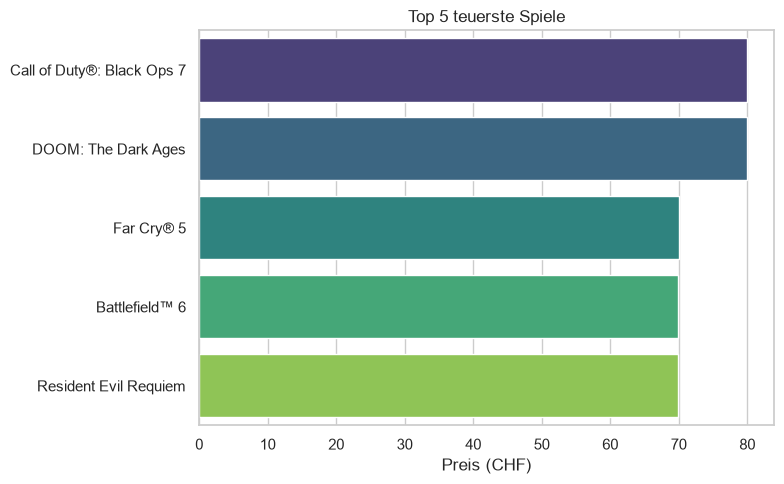

In [15]:
top5_teuer = df.sort_values('price', ascending=False).head(5)

print('Top 5 teuerste Spiele:')
print(top5_teuer[['name', 'price']].to_string(index=False))

plt.figure(figsize=(8, 5))
sns.barplot(data=top5_teuer, x='price', y='name', palette='viridis')
plt.title('Top 5 teuerste Spiele')
plt.xlabel('Preis (CHF)')
plt.ylabel('')
plt.tight_layout()
plt.savefig('top5_teuerste.png')
print('Diagramm gespeichert: top5_teuerste.png')
plt.show()

Spiele pro Erscheinungsjahr:
 release_year  anzahl_spiele
         2007              1
         2010              1
         2012              2
         2013              1
         2014              1
         2015              2
         2016              1
         2017              2
         2018              3
         2019              3
         2020              5
         2022              1
         2023              5
         2024              6
         2025             10
         2026              6
Diagramm gespeichert: spiele_pro_jahr.png


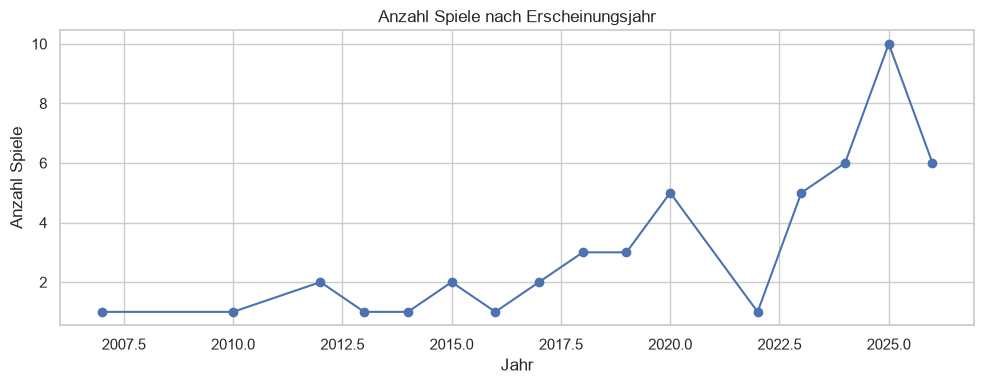

In [16]:
df['release_year'] = df['release_date_parsed'].dt.year  

pro_jahr = df.groupby('release_year', as_index=False)['name'].count()
pro_jahr = pro_jahr.rename(columns={'name': 'anzahl_spiele'})
pro_jahr = pro_jahr.sort_values('release_year')

print('Spiele pro Erscheinungsjahr:')
print(pro_jahr.to_string(index=False))

plt.figure(figsize=(10, 4))
plt.plot(pro_jahr['release_year'], pro_jahr['anzahl_spiele'], marker='o')
plt.title('Anzahl Spiele nach Erscheinungsjahr')
plt.xlabel('Jahr')
plt.ylabel('Anzahl Spiele')
plt.tight_layout()
plt.savefig('spiele_pro_jahr.png')
print('Diagramm gespeichert: spiele_pro_jahr.png')
plt.show()

In [17]:
from sqlalchemy import create_engine, text

df = pd.read_csv('clean_data.csv', parse_dates=['release_date_parsed'])
df.head()

,name,price_text,release_date,price,release_date_parsed
0,Counter-Strike 2,Free,"21 Aug, 2012",0.00,2012-08-21
1,Cyberpunk 2077,CHF 55.99,"9 Dec, 2020",55.99,2020-12-09
2,Team Fortress 2,Free,"10 Oct, 2007",0.00,2007-10-10
3,PUBG: BATTLEGROUNDS,Free,"21 Dec, 2017",0.00,2017-12-21
4,Apex Legends™,Free,"4 Nov, 2020",0.00,2020-11-04


In [18]:
db_user = 'apprentice'
db_pass = 'apprentice_pw'
db_host = 'localhost'
db_port = '5432'
db_name = 'apx_data'

conn_str = f'postgresql+psycopg://{db_user}:{db_pass}@{db_host}:{db_port}/{db_name}'

engine = create_engine(conn_str)
with engine.connect() as conn:
    result = conn.execute(text('select 1'))
    print('Verbindung erfolgreich:', result.fetchone())

Verbindung erfolgreich: (1,)


In [19]:
df.to_sql('steam_games', engine, if_exists='replace', index=False)
print('Zeilen in die Datenbank geladen:', len(df))

Zeilen in die Datenbank geladen: 50


In [20]:
check = pd.read_sql('select count(*) as row_count from steam_games', engine)
check

,row_count
0,50


In [21]:
teure = pd.read_sql('select name, price from steam_games where price > 30 order by price desc', engine)
teure

,name,price
0,DOOM: The Dark Ages,79.90
1,Call of Duty®: Black Ops 7,79.90
2,Far Cry® 5,69.99
3,Battlefield™ 6,69.90
4,Resident Evil Requiem,69.90
5,No Man's Sky,65.99
6,Halo: Campaign Evolved,59.90
7,Call of Duty®: Black Ops III,59.90
8,Cyberpunk 2077,55.99
9,Ready or Not,55.50


In [22]:
import hashlib

def parse_price(value):
    if pd.isna(value):
        return None
    if str(value) == 'Free':
        return 0.0
    try:
        s = str(value).replace(',', '.')
        s = ''.join(ch for ch in s if ch.isdigit() or ch == '.')
        return float(s) if s else None
    except Exception:
        return None

def make_unique_key_row(row):
    parts = [str(row.get('name', '')).strip().lower(), str(row.get('release_date', ''))]
    return hashlib.sha256('|'.join(parts).encode('utf-8')).hexdigest()

def clean_df(df):
    df = df.copy()
    df['release_date_parsed'] = pd.to_datetime(df.get('release_date'), errors='coerce')
    
    if 'price' not in df.columns or df['price'].isna().any():
        df['price'] = df['price_text'].apply(parse_price)
    
    df = df[df['name'].notna() & df['price'].notna()]
    
    df['unique_key'] = df.apply(make_unique_key_row, axis=1)
    df = df.drop_duplicates(subset=['unique_key'])
    
    return df

In [23]:
df_raw = pd.read_csv('raw_data.csv', encoding='utf-8')
df_clean = clean_df(df_raw)

print('Rohzeilen:', len(df_raw))
print('Bereinigte Zeilen:', len(df_clean))
df_clean.head()

Rohzeilen: 50
Bereinigte Zeilen: 50


,name,price_text,release_date,release_date_parsed,price,unique_key
0,Counter-Strike 2,Free,"21 Aug, 2012",2012-08-21,0.00,57ab35b42fbb59033bd989d0065a7e7b69d99d344aa265...
1,Cyberpunk 2077,CHF 55.99,"9 Dec, 2020",2020-12-09,55.99,4d2f6bc6d90cfe4d52a3c2d27adcb8c6e4e5c7fcacd559...
2,Team Fortress 2,Free,"10 Oct, 2007",2007-10-10,0.00,f66bbdda311583a57e4e5b9826fe3f695d8572b904b37a...
3,PUBG: BATTLEGROUNDS,Free,"21 Dec, 2017",2017-12-21,0.00,9d5157bc3767247695ee4d0bc61e796c6a5013e5f04702...
4,Apex Legends™,Free,"4 Nov, 2020",2020-11-04,0.00,d3f1900c61b052857242b017c788bad94b9966594cca83...


In [24]:
db_user = 'apprentice'
db_pass = 'apprentice_pw'
db_host = 'localhost'
db_port = '5432'
db_name = 'apx_data'

conn_str = f'postgresql+psycopg://{db_user}:{db_pass}@{db_host}:{db_port}/{db_name}'
engine = create_engine(conn_str)
with engine.connect() as conn:
    print('Verbindung erfolgreich:', conn.execute(text('select 1')).fetchone())

Verbindung erfolgreich: (1,)


In [26]:
df_clean.to_sql('steam_games', engine, if_exists='replace', index=False)
print('Zeilen geladen:', len(df_clean))

check = pd.read_sql('select count(*) as row_count from steam_games', engine)
check 

Zeilen geladen: 50


,row_count
0,50


In [27]:
schema_info = pd.read_sql("""
    SELECT column_name, data_type, is_nullable
    FROM information_schema.columns
    WHERE table_name = 'steam_games'
    ORDER BY ordinal_position
""", engine)

schema_info

,column_name,data_type,is_nullable
0,name,text,YES
1,price_text,text,YES
2,release_date,text,YES
3,release_date_parsed,timestamp without time zone,YES
4,price,double precision,YES
5,unique_key,text,YES


In [28]:
teuerste = pd.read_sql("""
    SELECT name, price, release_date
    FROM steam_games
    ORDER BY price DESC
    LIMIT 5
""", engine)

teuerste

,name,price,release_date
0,Call of Duty®: Black Ops 7,79.90,"13 Nov, 2025"
1,DOOM: The Dark Ages,79.90,"14 May, 2025"
2,Far Cry® 5,69.99,"26 Mar, 2018"
3,Battlefield™ 6,69.90,"10 Oct, 2025"
4,Resident Evil Requiem,69.90,"26 Feb, 2026"


In [29]:
print('Fehlende Werte pro Spalte:')
print(df_clean.isna().sum())

print()
print('Preis-Statistik:')
print(df_clean['price'].describe())

Fehlende Werte pro Spalte:
name                   0
price_text             0
release_date           0
release_date_parsed    0
price                  0
unique_key             0
dtype: int64

Preis-Statistik:
count    50.000000
mean     31.980000
std      24.541031
min       0.000000
25%       1.412500
50%      34.425000
75%      47.672500
max      79.900000
Name: price, dtype: float64
